<a href="https://colab.research.google.com/github/Kirtisheel1/data_cleaning_airbnb/blob/main/airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

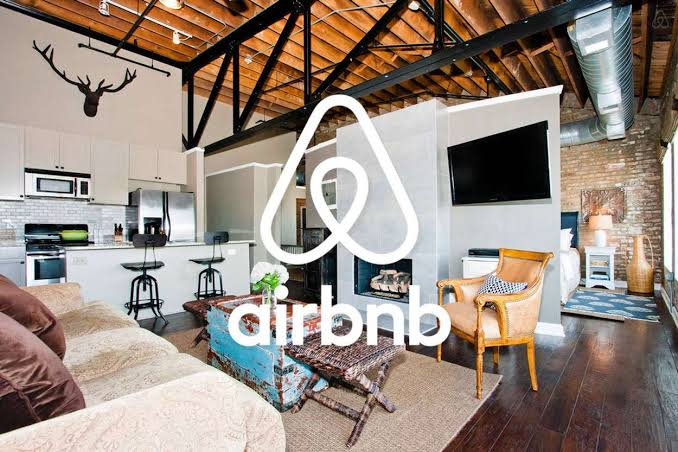

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [48]:
df = pd.read_csv("/content/Airbnb_Open_Data.csv", on_bad_lines='skip', engine="python")

# First, clean the string values in the column
#df['service fee'] = df['service fee'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['service fee'] = df['service fee'].astype(str).str.replace('$', '')
# Then convert the cleaned column to numeric values
#df['service fee'] = pd.to_numeric(df['service fee'], errors='coerce')
df['service fee'].dtype

dtype('O')

inspect the dataset


In [49]:
print('='* 200)
print('starting 10 data')
print('='* 200)
df.head(10)

starting 10 data


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN
5,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,...,115,3.0,74.0,6/22/2019,0.59,3.0,1.0,374.0,"No smoking, please, and no drugs.",NaN
6,1004650,BlissArtsSpace!,61300605564,NaN,Alberta,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,...,14,45.0,49.0,10/5/2017,0.40,5.0,1.0,224.0,Please no shoes in the house so bring slippers...,NaN
7,1005202,BlissArtsSpace!,90821839709,unconfirmed,Emma,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,...,212,45.0,49.0,10/5/2017,0.40,5.0,1.0,219.0,House Guidelines for our BnB We are delighted ...,NaN
8,1005754,Large Furnished Room Near B'way,79384379533,verified,Evelyn,Manhattan,Hell's Kitchen,40.76489,-73.98493,United States,...,204,2.0,430.0,6/24/2019,3.47,3.0,1.0,180.0,- Please clean up after yourself when using th...,NaN
9,1006307,Cozy Clean Guest Room - Family Apt,75527839483,unconfirmed,Carl,Manhattan,Upper West Side,40.80178,-73.96723,United States,...,58,2.0,118.0,7/21/2017,0.99,5.0,1.0,375.0,NO SMOKING OR PETS ANYWHERE ON THE PROPERTY 1....,NaN


In [50]:
print('='* 200)
print('ending 10 data')
print('='* 200)

df.tail(10)

ending 10 data


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
102589,6089676,Lrg room 1 block from Prospect Park,74549151787,unconfirmed,Dave,Brooklyn,Flatbush,40.65231,-73.96189,United States,...,61,3.0,0.0,NaN,NaN,1.0,1.0,200.0,House Rules 1. Check-in is 4 pm local time. If...,NaN
102590,6090228,Wonderful artists' loft in Brooklyn,9184535139,unconfirmed,Daniel,Brooklyn,Crown Heights,40.66673,-73.96127,United States,...,50,1.0,0.0,NaN,NaN,1.0,1.0,276.0,#NAME?,NaN
102591,6090781,Columbus Ave Apt 1 block from Park,50908010324,verified,Lawrence,Manhattan,Upper West Side,40.77408,-73.98181,United States,...,228,5.0,17.0,1/4/2019,0.35,5.0,1.0,134.0,#NAME?,NaN
102592,6091333,3BR/1 Ba in TriBeCa w/ outdoor deck,53266862889,unconfirmed,Nick,Manhattan,Tribeca,40.71845,-74.01183,United States,...,157,1.0,0.0,NaN,NaN,2.0,1.0,177.0,Guests should treat my home as if it were thei...,NaN
102593,6091885,"Welcoming, Clean, Cheap on St Marks",33188605074,verified,Felipe,Manhattan,East Village,40.72826,-73.98422,United States,...,220,1.0,8.0,9/6/2015,0.16,4.0,2.0,152.0,* No smoking indoors. * No pets * No loud/la...,NaN
102594,6092437,Spare room in Williamsburg,12312296767,verified,Krik,Brooklyn,Williamsburg,40.70862,-73.94651,United States,...,169,1.0,0.0,NaN,NaN,3.0,1.0,227.0,No Smoking No Parties or Events of any kind Pl...,NaN
102595,6092990,Best Location near Columbia U,77864383453,unconfirmed,Mifan,Manhattan,Morningside Heights,40.80460,-73.96545,United States,...,167,1.0,1.0,7/6/2015,0.02,2.0,2.0,395.0,House rules: Guests agree to the following ter...,NaN
102596,6093542,"Comfy, bright room in Brooklyn",69050334417,unconfirmed,Megan,Brooklyn,Park Slope,40.67505,-73.98045,United States,...,198,3.0,0.0,NaN,NaN,5.0,1.0,342.0,NaN,NaN
102597,6094094,Big Studio-One Stop from Midtown,11160591270,unconfirmed,Christopher,Queens,Long Island City,40.74989,-73.93777,United States,...,109,2.0,5.0,10/11/2015,0.10,3.0,1.0,386.0,NaN,NaN
102598,6094647,585 sf Luxury Studio,68170633372,unconfirmed,Rebecca,Manhattan,Upper West Side,40.76807,-73.98342,United States,...,206,1.0,0.0,NaN,NaN,3.0,1.0,69.0,NaN,NaN


In [51]:
df.dtypes

,0
id,int64
NAME,object
host id,int64
host_identity_verified,object
host name,object
neighbourhood group,object
neighbourhood,object
lat,float64
long,float64
country,object


In [52]:
print('='*200)
print('columns')
print('='*200)

index = 1
for i in df.columns:
  print(f'{index}.{i}')
  index += 1

columns
1.id
2.NAME
3.host id
4.host_identity_verified
5.host name
6.neighbourhood group
7.neighbourhood
8.lat
9.long
10.country
11.country code
12.instant_bookable
13.cancellation_policy
14.room type
15.Construction year
16.price
17.service fee
18.minimum nights
19.number of reviews
20.last review
21.reviews per month
22.review rate number
23.calculated host listings count
24.availability 365
25.house_rules
26.license


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [54]:
df.describe()

,id,host id,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,1.025990e+05,1.025990e+05,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,2.914623e+07,4.925411e+10,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,1.625751e+07,2.853900e+10,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,1.508581e+07,2.458333e+10,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,2.913660e+07,4.911774e+10,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,4.320120e+07,7.399650e+10,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


In [55]:
df.drop('license', axis = 1,inplace = True)

In [56]:
from os import error
print('='*200)
print('remove the nan values')
print('='*200)
df['service fee'] = pd.to_numeric(df['service fee'],errors='coerce')


remove the nan values


In [57]:
df.isnull().sum()


,0
id,0
NAME,250
host id,0
host_identity_verified,289
host name,406
neighbourhood group,29
neighbourhood,16
lat,8
long,8
country,532


In [58]:
print('='* 200)
print('drop all null values')
print('='* 200)
df.dropna(inplace=True)

drop all null values


In [59]:
print('='*200)
print('drop the unwanted columns')
print('='*200)
data = ['reviews per month','availability 365']
df.drop(data,axis=1,inplace=True)

drop the unwanted columns


In [60]:
print('='*200)
print('Ther are zero duplicated values')
print('='*200)
df.duplicated().sum()


Ther are zero duplicated values


np.int64(212)

In [61]:
data = {'NAME':'Name'}
df.rename(columns = data)


,id,Name,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,review rate number,calculated host listings count,house_rules
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,Private room,2020.0,$966,193.0,10.0,9.0,10/19/2021,4.0,6.0,Clean up and treat the home the way you'd like...
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,Entire home/apt,2007.0,$142,28.0,30.0,45.0,5/21/2022,4.0,2.0,Pet friendly but please confirm with me if the...
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,Entire home/apt,2009.0,$204,41.0,10.0,9.0,11/19/2018,3.0,1.0,"Please no smoking in the house, porch or on th..."
5,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,United States,...,Entire home/apt,2013.0,$577,115.0,3.0,74.0,6/22/2019,3.0,1.0,"No smoking, please, and no drugs."
7,1005202,BlissArtsSpace!,90821839709,unconfirmed,Emma,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,United States,...,Private room,2009.0,"$1,060",212.0,45.0,49.0,10/5/2017,5.0,1.0,House Guidelines for our BnB We are delighted ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102587,6088571,Adorable One-Bed in Williamsburg!,20914678851,verified,Taylor,Brooklyn,Williamsburg,40.71687,-73.94656,United States,...,Entire home/apt,2005.0,$388,78.0,1.0,66.0,6/16/2019,2.0,1.0,• Check-in time is 2PM. Check-out time is 11am...
102588,6089124,"Loft Space for Events, Meetings & Shoots",85557432222,unconfirmed,Kalin,Manhattan,Flatiron District,40.74068,-73.98999,United States,...,Entire home/apt,2016.0,$618,124.0,1.0,177.0,6/29/2019,4.0,1.0,Keep the apartment clean and damage free please.
102591,6090781,Columbus Ave Apt 1 block from Park,50908010324,verified,Lawrence,Manhattan,Upper West Side,40.77408,-73.98181,United States,...,Entire home/apt,2005.0,"$1,139",228.0,5.0,17.0,1/4/2019,5.0,1.0,#NAME?
102593,6091885,"Welcoming, Clean, Cheap on St Marks",33188605074,verified,Felipe,Manhattan,East Village,40.72826,-73.98422,United States,...,Private room,2017.0,"$1,099",220.0,1.0,8.0,9/6/2015,4.0,2.0,* No smoking indoors. * No pets * No loud/la...


In [62]:
df['host_identity_verified'] = df['host_identity_verified'].str.upper()

In [63]:
df.reset_index(inplace=True)

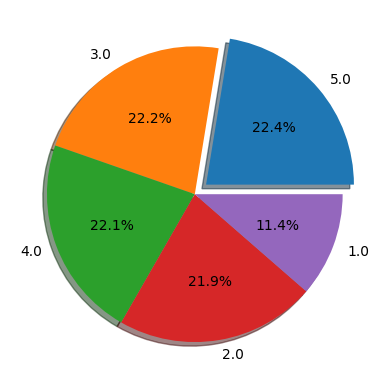

,count
review rate number,
5.0,8884
3.0,8812
4.0,8741
2.0,8670
1.0,4520


In [64]:
counts = df['review rate number'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%',explode=[0.1,0.0,0,0,0],shadow = True)
plt.show()
counts

In [65]:
df.to_csv('clean_airbnb.csv', index=False)

In [67]:
df2 = pd.read_csv('/content/clean_airbnb.csv')
df2

,index,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,...,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,review rate number,calculated host listings count,house_rules
0,0,1001254,Clean & quiet apt home by the park,80014485718,UNCONFIRMED,Madaline,Brooklyn,Kensington,40.64749,-73.97237,...,Private room,2020.0,$966,193.0,10.0,9.0,10/19/2021,4.0,6.0,Clean up and treat the home the way you'd like...
1,1,1002102,Skylit Midtown Castle,52335172823,VERIFIED,Jenna,Manhattan,Midtown,40.75362,-73.98377,...,Entire home/apt,2007.0,$142,28.0,30.0,45.0,5/21/2022,4.0,2.0,Pet friendly but please confirm with me if the...
2,4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,VERIFIED,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,...,Entire home/apt,2009.0,$204,41.0,10.0,9.0,11/19/2018,3.0,1.0,"Please no smoking in the house, porch or on th..."
3,5,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,VERIFIED,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,...,Entire home/apt,2013.0,$577,115.0,3.0,74.0,6/22/2019,3.0,1.0,"No smoking, please, and no drugs."
4,7,1005202,BlissArtsSpace!,90821839709,UNCONFIRMED,Emma,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,...,Private room,2009.0,"$1,060",212.0,45.0,49.0,10/5/2017,5.0,1.0,House Guidelines for our BnB We are delighted ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39622,102587,6088571,Adorable One-Bed in Williamsburg!,20914678851,VERIFIED,Taylor,Brooklyn,Williamsburg,40.71687,-73.94656,...,Entire home/apt,2005.0,$388,78.0,1.0,66.0,6/16/2019,2.0,1.0,• Check-in time is 2PM. Check-out time is 11am...
39623,102588,6089124,"Loft Space for Events, Meetings & Shoots",85557432222,UNCONFIRMED,Kalin,Manhattan,Flatiron District,40.74068,-73.98999,...,Entire home/apt,2016.0,$618,124.0,1.0,177.0,6/29/2019,4.0,1.0,Keep the apartment clean and damage free please.
39624,102591,6090781,Columbus Ave Apt 1 block from Park,50908010324,VERIFIED,Lawrence,Manhattan,Upper West Side,40.77408,-73.98181,...,Entire home/apt,2005.0,"$1,139",228.0,5.0,17.0,1/4/2019,5.0,1.0,#NAME?
39625,102593,6091885,"Welcoming, Clean, Cheap on St Marks",33188605074,VERIFIED,Felipe,Manhattan,East Village,40.72826,-73.98422,...,Private room,2017.0,"$1,099",220.0,1.0,8.0,9/6/2015,4.0,2.0,* No smoking indoors. * No pets * No loud/la...
